In [135]:
import numpy as np
import tensorflow as tf
from tensorflow import keras

import keras
from keras import layers
from keras import ops
from tensorflow.keras.models import Sequential
import keras_tuner as kt

from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

import random
import time

print(f"TensorFlow {tf.__version__}")
print(f"GPUs: {tf.config.list_physical_devices('GPU')}")

TensorFlow 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
pileups = np.load("pileup_waveforms.npz")
X_pileup = pileups["pileup_wf"].astype(np.float32)

y_1 = pileups["primary_label"]       
y_2 = pileups["secondary_label"]    

# combine targets: one row per X sample
Y = np.column_stack([y_1, y_2]).astype(np.int32)   # shape (n_samples, 2)

X_train, X_test, Y_train, Y_test = train_test_split(
    X_pileup, Y,
    test_size=0.2,
    random_state=42)


#Normalize to [0,1] range
minv = X_train.min(axis=0, keepdims=True)    
maxv = X_train.max(axis=0, keepdims=True)   
den  = np.maximum(maxv - minv, 1e-8)

X_train_n = (X_train - minv) / den
X_test_n  = (X_test  - minv) / den

  # (N, 104, 1) reshape for CNN 
X_train_n = X_train_n[..., None] 
X_test_n  = X_test_n[..., None]

In [ ]:
input_length = np.shape(X_train_n)[1]
latent_dim = 16 #artbitrary previously tried 8 with worse results

inputs = tf.keras.Input(shape=(input_length, 1))

#  Encoder 
x = layers.Conv1D(32, 3, activation='relu', padding='same')(inputs)
x = layers.MaxPooling1D(2, padding='same')(x)   # 104 → 52

x = layers.Conv1D(64, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling1D(2, padding='same')(x)   # 52 → 26

x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling1D(2, padding='same')(x)   # 26 → 13

shape_before_flatten = x.shape[1:]  # (13, 128)

#bottleneck 
x = layers.Flatten()(x)
latent = layers.Dense(latent_dim, name="latent")(x)

#  Decoder 
x = layers.Dense(shape_before_flatten[0] * shape_before_flatten[1], activation='relu')(latent)
x = layers.Reshape(shape_before_flatten)(x)

x = layers.UpSampling1D(2)(x)  # 13 → 26
x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)

x = layers.UpSampling1D(2)(x)  # 26 → 52
x = layers.Conv1D(64, 3, activation='relu', padding='same')(x)

x = layers.UpSampling1D(2)(x)  # 52 → 104
x = layers.Conv1D(32, 3, activation='relu', padding='same')(x)

reconstruction = layers.Conv1D(1, 3, padding='same', name="reconstruction")(x)

#  Classifier 
clf = layers.Dense(32, activation='relu')(latent)
clf = layers.Dense(16, activation='relu')(clf)
classification = layers.Dense(2, activation='sigmoid', name="classification")(clf)

#  Model (Encoder + classifier)
model = Model(inputs, [reconstruction, classification])

In [138]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss={
        "reconstruction": "mse",
        "classification": "binary_crossentropy"
    },
    loss_weights={
        "reconstruction": 1,
        "classification": 1
    },
    metrics={
        "classification": ["accuracy"]
    }
)

In [ ]:
history = model.fit(
    X_train,
    {"reconstruction": X_train_n,
      "classification": Y_train},
    validation_data=(
        X_test,
        {"reconstruction": X_test_n,
         "classification": Y_test}
    ),
    epochs=50,
    batch_size=256
)

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - classification_accuracy: 0.6689 - classification_loss: 0.2933 - loss: 0.1181 - reconstruction_loss: 0.0014 - val_classification_accuracy: 0.7225 - val_classification_loss: 0.1951 - val_loss: 0.0786 - val_reconstruction_loss: 8.5990e-04
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - classification_accuracy: 0.7264 - classification_loss: 0.1800 - loss: 0.0725 - reconstruction_loss: 8.3339e-04 - val_classification_accuracy: 0.7359 - val_classification_loss: 0.1635 - val_loss: 0.0659 - val_reconstruction_loss: 7.6727e-04
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - classification_accuracy: 0.7391 - classification_loss: 0.1612 - loss: 0.0649 - reconstruction_loss: 7.4771e-04 - val_classification_accuracy: 0.7369 - val_classification_loss: 0.1595 - val_loss: 0.0643 - val_reconstruction_loss: 8.2586e-04
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - classification_accuracy: 0.7470 - classification_loss: 0.153

2500/2500 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


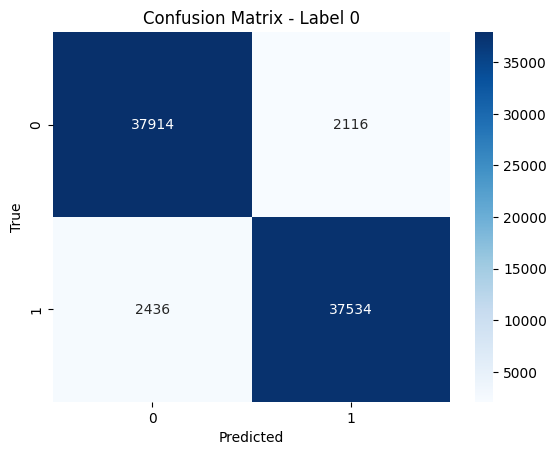

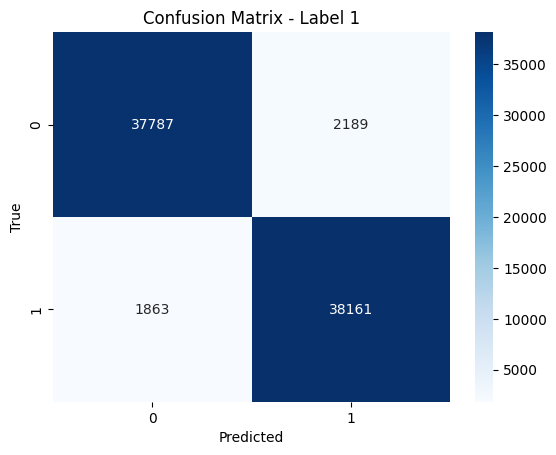

In [ ]:
# Get predictions
y_pred = model.predict(X_test)[1]

# Convert probabilities to 0 or 1 
y_pred_bin = (y_pred > 0.5).astype(int)

# Plot confusion matrix for each label
for i in range(Y_test.shape[1]):
    cm = confusion_matrix(Y_test[:, i], y_pred_bin[:, i])
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - Label {i}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

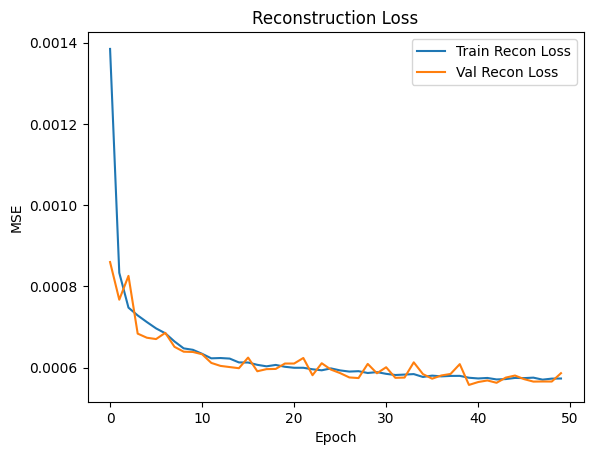

In [142]:
plt.figure()
plt.plot(history.history['reconstruction_loss'], label='Train Recon Loss')
plt.plot(history.history['val_reconstruction_loss'], label='Val Recon Loss')
plt.title('Reconstruction Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

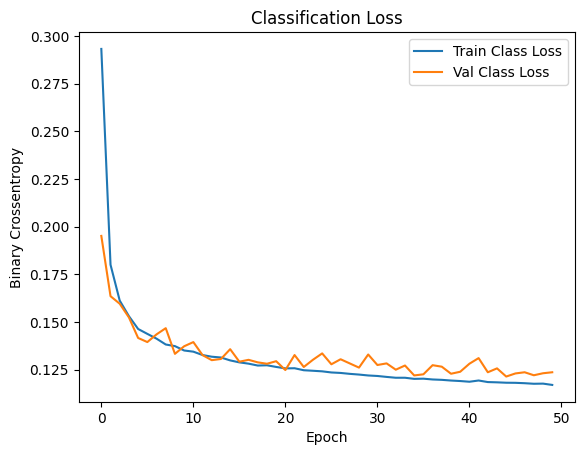

In [143]:
plt.figure()
plt.plot(history.history['classification_loss'], label='Train Class Loss')
plt.plot(history.history['val_classification_loss'], label='Val Class Loss')
plt.title('Classification Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy')
plt.legend()
plt.show()

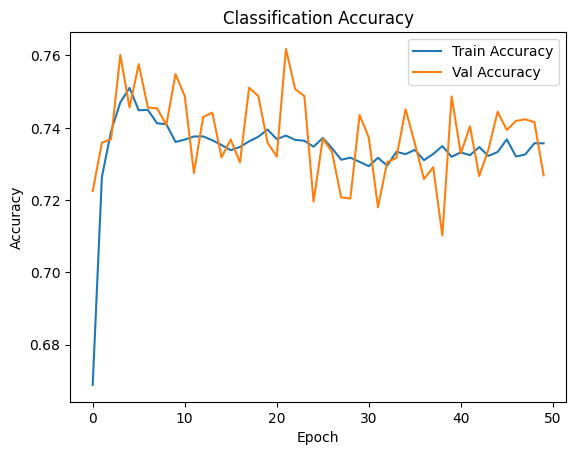

In [144]:
plt.figure()
plt.plot(history.history['classification_accuracy'], label='Train Accuracy')
plt.plot(history.history['val_classification_accuracy'], label='Val Accuracy')
plt.title('Classification Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [131]:
#Test without autoencoder 

#Classifier only 
inputs = tf.keras.Input(shape=(104,))
x = layers.Dense(32, activation='relu')(inputs)
x = layers.Dense(16, activation='relu')(x)

outputs = layers.Dense(2, activation='sigmoid')(x)

base_model = Model(inputs, outputs)

base_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

base_model_history = base_model.fit(
    X_train,
    Y_train,
    validation_data=(X_test, Y_test),
    epochs=30,
    batch_size=256,
    verbose=1
)

Epoch 1/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6647 - loss: 0.6757 - val_accuracy: 0.7457 - val_loss: 0.6954
Epoch 2/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7492 - loss: 0.7570 - val_accuracy: 0.7482 - val_loss: 0.7009
Epoch 3/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7499 - loss: 1.0652 - val_accuracy: 0.7486 - val_loss: 2.3673
Epoch 4/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7502 - loss: 1.5133 - val_accuracy: 0.7484 - val_loss: 0.8208
Epoch 5/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7502 - loss: 2.0454 - val_accuracy: 0.7485 - val_loss: 1.1242
Epoch 6/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7503 - loss: 3.2033 - val_accuracy: 0.7486 - val_loss: 4.6972
Epoch 7/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7503 - loss: 4.3933 - val_accuracy: 0.7486 - val_loss: 7.1842
Epoch 8/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7503 - loss: 4.7778 - 

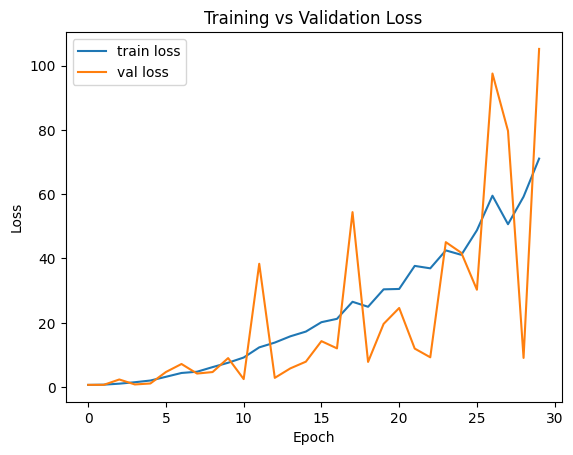

In [132]:
import matplotlib.pyplot as plt

plt.plot(base_model_history.history['loss'], label='train loss')
plt.plot(base_model_history.history['val_loss'], label='val loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

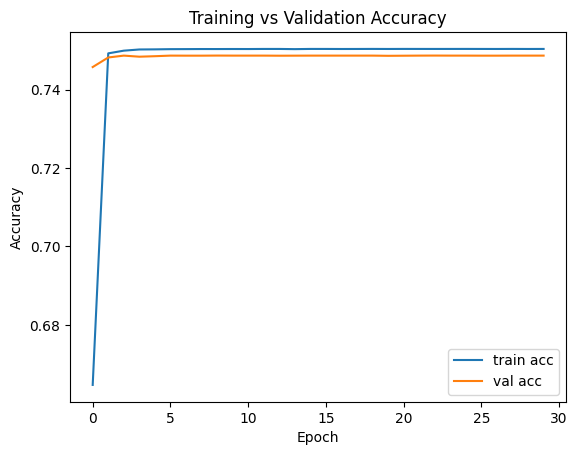

In [133]:
plt.plot(base_model_history.history["accuracy"], label="train acc")
plt.plot(base_model_history.history["val_accuracy"], label="val acc")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

2500/2500 ━━━━━━━━━━━━━━━━━━━━ 2s 772us/step


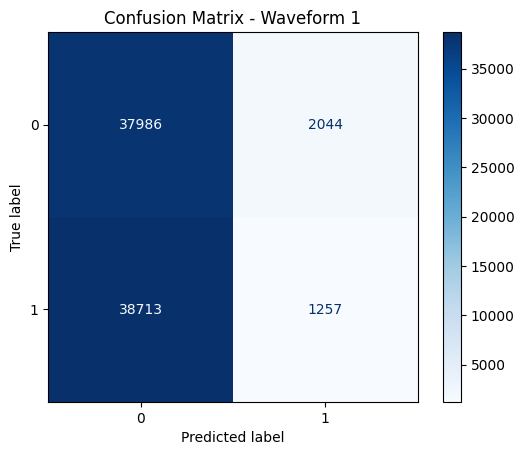

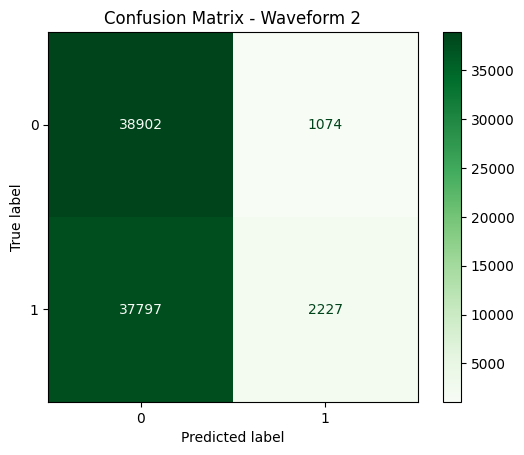

In [134]:
import numpy as np

y_pred_probs = base_model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)
y_true = Y_test.astype(int)

cm0 = confusion_matrix(y_true[:, 0], y_pred[:, 0])

disp0 = ConfusionMatrixDisplay(cm0)
disp0.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Waveform 1")
plt.show()


cm1 = confusion_matrix(y_true[:, 1], y_pred[:, 1])

disp1 = ConfusionMatrixDisplay(cm1)
disp1.plot(cmap="Greens", values_format="d")
plt.title("Confusion Matrix - Waveform 2")
plt.show()